<a href="https://colab.research.google.com/github/Msubhashana/Deep-Learning-eye-diseases-classification/blob/mahima---Custom-CNN/custom_cnn_cassava.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install dependencies
!pip install -q kaggle split-folders tensorflow scikit-learn seaborn

In [3]:
# Kaggle API authentication via environment variables (secure, no kaggle.json file)
import os
from getpass import getpass

try:
    from google.colab import userdata
    KAGGLE_USERNAME = userdata.get('KAGGLE_USERNAME')
    KAGGLE_KEY = userdata.get('KAGGLE_KEY')
except Exception:
    KAGGLE_USERNAME = None
    KAGGLE_KEY = None

os.environ['KAGGLE_USERNAME'] = KAGGLE_USERNAME
os.environ['KAGGLE_KEY'] = KAGGLE_KEY

print("Kaggle credentials set in environment")

Kaggle credentials set in environment


In [4]:
# Download and extract the dataset using the Kaggle CLI (reads env vars automatically)
DATA_ROOT = "/content/eye_diseases_raw"
os.makedirs(DATA_ROOT, exist_ok=True)

!kaggle datasets download -d gunavenkatdoddi/eye-diseases-classification -p {DATA_ROOT} --force
!unzip -q -o {DATA_ROOT}/eye-diseases-classification.zip -d {DATA_ROOT}

# Inspect folder structure to find the actual class-folder root
for root, dirs, files in os.walk(DATA_ROOT):
    if files and any(f.lower().endswith(('.jpg', '.jpeg', '.png')) for f in files):
        print(root, "->", len(files), "images")

Dataset URL: https://www.kaggle.com/datasets/gunavenkatdoddi/eye-diseases-classification
License(s): ODbL-1.0
100% 736M/736M [00:07<00:00, 108MB/s]

/content/eye_diseases_raw/dataset/diabetic_retinopathy -> 1098 images
/content/eye_diseases_raw/dataset/cataract -> 1038 images
/content/eye_diseases_raw/dataset/glaucoma -> 1007 images
/content/eye_diseases_raw/dataset/normal -> 1074 images


In [5]:
# Imports
import shutil
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import splitfolders
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve,
                              auc, precision_recall_fscore_support)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [6]:
# Locate the class-folder directory produced by the dataset
# The Kaggle dataset unzips into a nested "dataset" folder containing one
# subfolder per class: cataract, diabetic_retinopathy, glaucoma, normal

CANDIDATES = glob.glob(f"{DATA_ROOT}/**/dataset", recursive=True)
SOURCE_DIR = CANDIDATES[0] if CANDIDATES else DATA_ROOT
print("Using source directory:", SOURCE_DIR)
print("Classes found:", os.listdir(SOURCE_DIR))

Using source directory: /content/eye_diseases_raw/dataset
Classes found: ['diabetic_retinopathy', 'cataract', 'glaucoma', 'normal']


In [7]:
# Stratified train/val/test split (prevents data leakage - done ONCE, before any preprocessing)

SPLIT_DIR = "/content/eye_diseases_split"
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

splitfolders.ratio(
    SOURCE_DIR,
    output=SPLIT_DIR,
    seed=SEED,
    ratio=(0.70, 0.15, 0.15),   # train / val / test
    group_prefix=None,
    move=False
)

TRAIN_DIR = f"{SPLIT_DIR}/train"
VAL_DIR   = f"{SPLIT_DIR}/val"
TEST_DIR  = f"{SPLIT_DIR}/test"

CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)
print("Classes:", CLASS_NAMES)

for split, d in [("train", TRAIN_DIR), ("val", VAL_DIR), ("test", TEST_DIR)]:
    counts = {c: len(os.listdir(os.path.join(d, c))) for c in CLASS_NAMES}
    print(split, counts)

Copying files: 4217 files [00:05, 811.27 files/s]

Classes: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
train {'cataract': 726, 'diabetic_retinopathy': 768, 'glaucoma': 704, 'normal': 751}
val {'cataract': 155, 'diabetic_retinopathy': 164, 'glaucoma': 151, 'normal': 161}
test {'cataract': 157, 'diabetic_retinopathy': 166, 'glaucoma': 152, 'normal': 162}


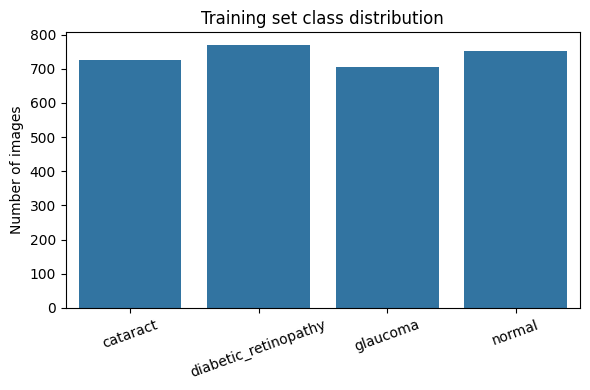

In [8]:
# Exploratory Data Analysis - class distribution plot
train_counts = {c: len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in CLASS_NAMES}
plt.figure(figsize=(6, 4))
sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()))
plt.title("Training set class distribution")
plt.ylabel("Number of images")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("/content/class_distribution.png", dpi=150)
plt.show()

In [9]:
# Preprocessing pipeline
# ResNet50 expects 224x224 inputs and its own channel-wise mean-subtraction
# (handled by preprocess_input, NOT simple /255 rescaling).

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, label_mode='categorical', image_size=IMG_SIZE,
    batch_size=BATCH_SIZE, seed=SEED, shuffle=True
)
val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, label_mode='categorical', image_size=IMG_SIZE,
    batch_size=BATCH_SIZE, seed=SEED, shuffle=False
)
test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, label_mode='categorical', image_size=IMG_SIZE,
    batch_size=BATCH_SIZE, seed=SEED, shuffle=False
)

# Data augmentation - applied ONLY to the training set, inside the model graph
# so it runs on-GPU and only during training (val/test pass through untouched).
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
    layers.RandomBrightness(0.10),
], name="data_augmentation")

def make_pipeline(ds, training=False):
    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32), y),
                num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    # ResNet50-specific preprocessing (BGR conversion + ImageNet mean subtraction)
    ds = ds.map(lambda x, y: (preprocess_input(x), y),
                num_parallel_calls=tf.data.AUTOTUNE)
    return ds.cache().prefetch(tf.data.AUTOTUNE)

train_ds = make_pipeline(train_ds_raw, training=True)
val_ds   = make_pipeline(val_ds_raw, training=False)
test_ds  = make_pipeline(test_ds_raw, training=False)

# Class weights to counter class imbalance (computed from TRAIN split only)
y_train_labels = []
for c_idx, c in enumerate(CLASS_NAMES):
    y_train_labels += [c_idx] * train_counts[c]
class_weights_arr = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES),
                                          y=np.array(y_train_labels))
class_weight_dict = dict(enumerate(class_weights_arr))
print("Class weights:", class_weight_dict)

Found 2949 files belonging to 4 classes.
Found 631 files belonging to 4 classes.
Found 637 files belonging to 4 classes.
Class weights: {0: np.float64(1.015495867768595), 1: np.float64(0.9599609375), 2: np.float64(1.0472301136363635), 3: np.float64(0.9816910785619174)}


In [10]:
# Build the ResNet50 model (transfer learning)
def build_resnet50(num_classes, img_size=(224, 224), fine_tune=False, unfreeze_from=143):
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=img_size + (3,)
    )
    base_model.trainable = fine_tune
    if fine_tune:
        for layer in base_model.layers[:unfreeze_from]:
            layer.trainable = False

    inputs = layers.Input(shape=img_size + (3,))
    x = base_model(inputs, training=fine_tune)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name="ResNet50_EyeDisease")
    return model, base_model

model, base_model = build_resnet50(NUM_CLASSES, IMG_SIZE, fine_tune=False)
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ResNet50_EyeDisease"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,121,476 (92.02 MB)

 Trainable params: 529,668 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [11]:
# Phase 1 - train the classification head with the ResNet50 base frozen

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
checkpoint = callbacks.ModelCheckpoint('/content/resnet50_best_phase1.keras',
                                       monitor='val_loss', save_best_only=True)

EPOCHS_PHASE1 = 20
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 87s 724ms/step - accuracy: 0.7616 - auc: 0.9276 - loss: 0.8572 - precision: 0.7740 - recall: 0.7491 - val_accuracy: 0.8035 - val_auc: 0.9460 - val_loss: 0.6235 - val_precision: 0.8240 - val_recall: 0.7718 - learning_rate: 0.0010
Epoch 2/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.8769 - auc: 0.9805 - loss: 0.3861 - precision: 0.8838 - recall: 0.8691 - val_accuracy: 0.7940 - val_auc: 0.9370 - val_loss: 0.6950 - val_precision: 0.8083 - val_recall: 0.7750 - learning_rate: 0.0010
Epoch 3/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.9220 - auc: 0.9909 - loss: 0.2652 - precision: 0.9260 - recall: 0.9162 - val_accuracy: 0.8019 - val_auc: 0.9421 - val_loss: 0.7028 - val_precision: 0.8127 - val_recall: 0.7908 - learning_rate: 0.0010
Epoch 4/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - accuracy: 0.9386 - auc: 0.9942 - loss: 0.2154 - precision: 0.9429 - recall: 0.9352 - val_accuracy: 0.8082 - val_auc: 0.9461 - val_loss: 0.6907 -

In [12]:
# Phase 2 - fine-tune: unfreeze the top portion of ResNet50 with a low LR

base_model.trainable = True
FINE_TUNE_AT = 143  # unfreeze from this layer index onward (roughly the last residual block)
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

checkpoint_ft = callbacks.ModelCheckpoint('/content/resnet50_best_finetuned.keras',
                                          monitor='val_loss', save_best_only=True)

EPOCHS_PHASE2 = 15
history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, checkpoint_ft]
)

Epoch 1/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 55s 346ms/step - accuracy: 0.9118 - auc: 0.9866 - loss: 0.3180 - precision: 0.9187 - recall: 0.9081 - val_accuracy: 0.8494 - val_auc: 0.9673 - val_loss: 0.5413 - val_precision: 0.8530 - val_recall: 0.8463 - learning_rate: 1.0000e-05
Epoch 2/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 15s 161ms/step - accuracy: 0.9756 - auc: 0.9992 - loss: 0.1287 - precision: 0.9769 - recall: 0.9736 - val_accuracy: 0.8431 - val_auc: 0.9637 - val_loss: 0.5884 - val_precision: 0.8491 - val_recall: 0.8384 - learning_rate: 1.0000e-05
Epoch 3/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 15s 163ms/step - accuracy: 0.9888 - auc: 0.9998 - loss: 0.0992 - precision: 0.9901 - recall: 0.9864 - val_accuracy: 0.8431 - val_auc: 0.9659 - val_loss: 0.5817 - val_precision: 0.8516 - val_recall: 0.8368 - learning_rate: 1.0000e-05
Epoch 4/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 15s 157ms/step - accuracy: 0.9932 - auc: 0.9999 - loss: 0.0853 - precision: 0.9946 - recall: 0.9929 - val_accuracy: 0.8320 - val_auc: 0.9624 - val_lo

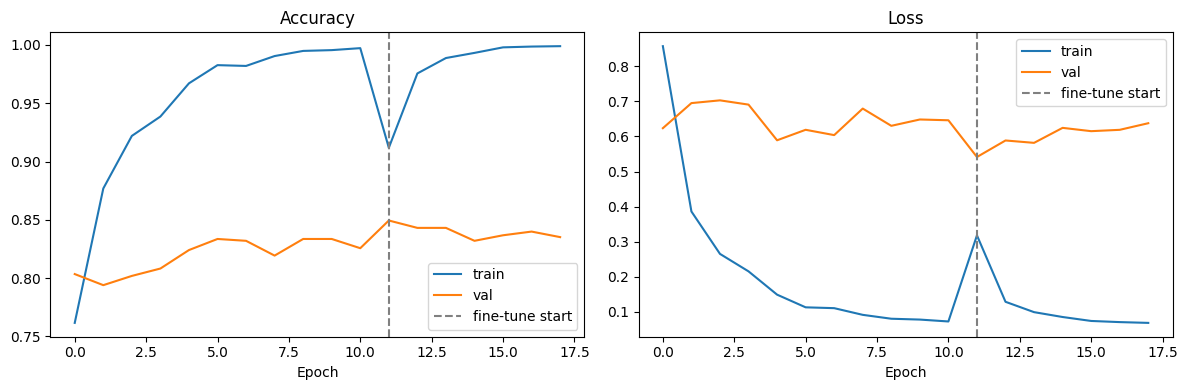

In [13]:
# Plot training curves (combine both phases)
def combine_history(h1, h2, key):
    return h1.history[key] + h2.history[key]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for key, ax, title in [('accuracy', axes[0], 'Accuracy'), ('loss', axes[1], 'Loss')]:
    ax.plot(combine_history(history_phase1, history_phase2, key), label='train')
    ax.plot(combine_history(history_phase1, history_phase2, f'val_{key}'), label='val')
    ax.axvline(x=len(history_phase1.history[key]), color='gray', linestyle='--', label='fine-tune start')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
plt.tight_layout()
plt.savefig("/content/training_curves.png", dpi=150)
plt.show()

In [14]:
# Final evaluation on the UNSEEN TEST SET ONLY
test_results = model.evaluate(test_ds, return_dict=True)
print("Test set results:", test_results)

y_true, y_pred_probs = [], []
for x_batch, y_batch in test_ds:
    preds = model.predict(x_batch, verbose=0)
    y_pred_probs.append(preds)
    y_true.append(y_batch.numpy())

y_true = np.concatenate(y_true)
y_pred_probs = np.concatenate(y_pred_probs)
y_true_labels = np.argmax(y_true, axis=1)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_true_labels, y_pred_labels, target_names=CLASS_NAMES))

precision, recall, f1, _ = precision_recall_fscore_support(y_true_labels, y_pred_labels, average='weighted')
print(f"Weighted Precision: {precision:.4f} | Recall: {recall:.4f} | F1-score: {f1:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 687ms/step - accuracy: 0.8289 - auc: 0.9595 - loss: 0.6378 - precision: 0.8349 - recall: 0.8257
Test set results: {'accuracy': 0.8288853764533997, 'auc': 0.9595126509666443, 'loss': 0.6378052830696106, 'precision': 0.8349206447601318, 'recall': 0.825745701789856}

Classification Report:

                      precision    recall  f1-score   support

            cataract       0.90      0.96      0.93       157
diabetic_retinopathy       0.77      0.91      0.83       166
            glaucoma       0.88      0.73      0.80       152
              normal       0.78      0.71      0.74       162

            accuracy                           0.83       637
           macro avg       0.83      0.83      0.83       637
        weighted avg       0.83      0.83      0.83       637

Weighted Precision: 0.8314 | Recall: 0.8289 | F1-score: 0.8264


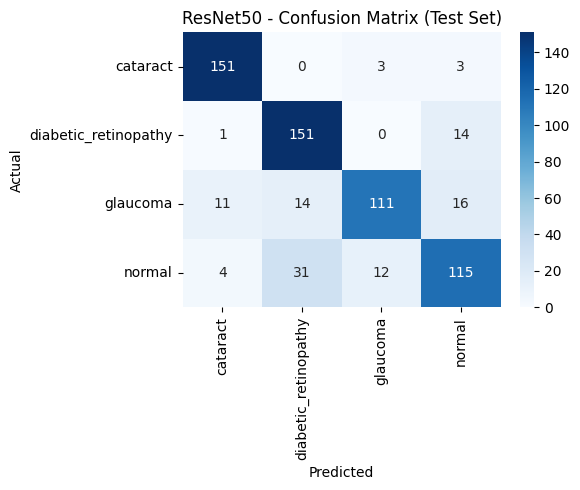

In [15]:
# Confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('ResNet50 - Confusion Matrix (Test Set)')
plt.tight_layout()
plt.savefig("/content/confusion_matrix.png", dpi=150)
plt.show()

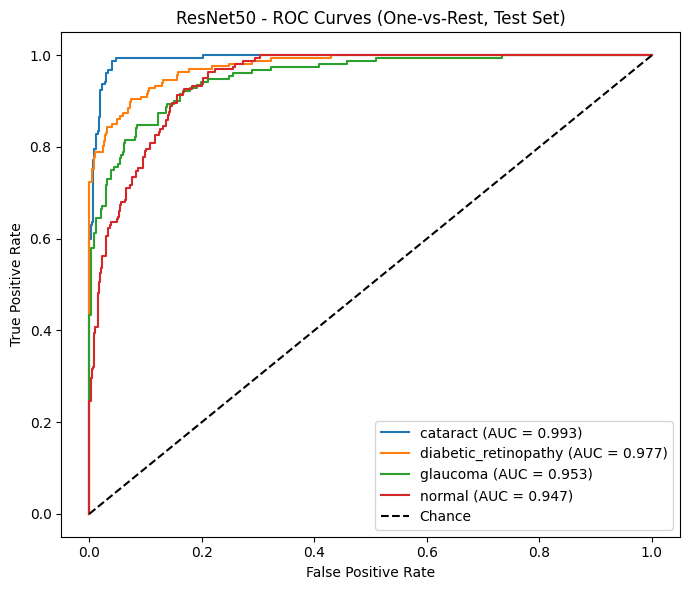

In [16]:
# Multi-class ROC-AUC (One-vs-Rest)
y_true_bin = label_binarize(y_true_labels, classes=list(range(NUM_CLASSES)))

plt.figure(figsize=(7, 6))
for i, class_name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ResNet50 - ROC Curves (One-vs-Rest, Test Set)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("/content/roc_curves.png", dpi=150)
plt.show()

In [17]:
# Save the final model + a summary CSV for the report's results table

model.save('/content/resnet50_eye_disease_final.keras')

summary_df = pd.DataFrame([{
    'model': 'ResNet50 (transfer learning + fine-tuned)',
    'test_accuracy': test_results['accuracy'],
    'test_auc': test_results['auc'],
    'test_precision': test_results['precision'],
    'test_recall': test_results['recall'],
    'weighted_f1': f1
}])
summary_df.to_csv('/content/resnet50_results_summary.csv', index=False)
print(summary_df)

                                       model  test_accuracy  test_auc  \
0  ResNet50 (transfer learning + fine-tuned)       0.828885  0.959513   

   test_precision  test_recall  weighted_f1  
0        0.834921     0.825746     0.826374  
